# 02 — Retrieval evidence

This notebook summarizes the measured retrieval progression. The values are labeled by experiment/budget so unlike cutoffs are not presented as directly comparable Recall@20 measurements.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "reports").exists():
    ROOT = ROOT.parent

def load_json(name):
    return json.loads((ROOT / "reports" / "metrics" / name).read_text())


In [2]:
r = load_json("retrieval_summary.json")
pd.DataFrame([
    ["baseline", "weighted Recall@20", r["baseline_weighted_recall_at_20"]],
    ["revisit + time", "weighted Recall@20", r["revisit_time_weighted_recall_at_20"]],
    ["co-visitation union", "high-budget weighted recall", r["covisit_high_budget_weighted_recall"]],
    ["co-visitation + Item2Vec", "weighted union recall at Item2Vec k=800", r["covisit_plus_item2vec_k800_weighted_recall"]],
], columns=["retrieval stage", "measurement", "recall"])

,retrieval stage,measurement,recall
0,baseline,weighted Recall@20,0.485256
1,revisit + time,weighted Recall@20,0.549644
2,co-visitation union,high-budget weighted recall,0.706430
3,co-visitation + Item2Vec,weighted union recall at Item2Vec k=800,0.732203


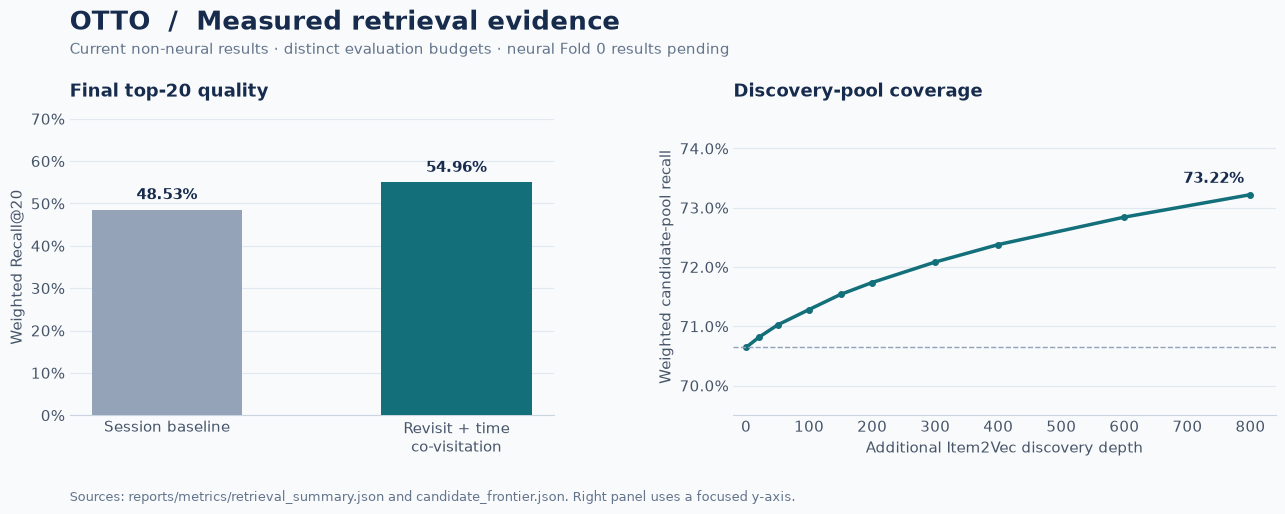

In [3]:
from matplotlib.ticker import PercentFormatter

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#cbd5e1",
    "text.color": "#172b4d", "axes.labelcolor": "#475569",
    "xtick.color": "#475569", "ytick.color": "#475569",
    "svg.hashsalt": "otto-retrieval-evidence",
})
fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.2), gridspec_kw={"width_ratios": [1, 1.12]})
fig.patch.set_facecolor("#f8fafc")
for ax in axes:
    ax.set_facecolor("#f8fafc")
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#e2e8f0", linewidth=0.8)
    ax.tick_params(length=0)

values = [r["baseline_weighted_recall_at_20"], r["revisit_time_weighted_recall_at_20"]]
axes[0].bar(["Session baseline", "Revisit + time\nco-visitation"], values,
            width=0.52, color=["#94a3b8", "#136f7a"], zorder=3)
for i, value in enumerate(values):
    axes[0].text(i, value + 0.025, f"{value:.2%}", ha="center", fontweight="bold")
axes[0].set_ylim(0, 0.7)
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_title("Final top-20 quality", loc="left", fontweight="bold", pad=16)
axes[0].set_ylabel("Weighted Recall@20")

frontier = load_json("candidate_frontier.json")
depths = [row["item2vec_k"] for row in frontier["points"]]
coverage = [row["weighted_union_recall"] for row in frontier["points"]]
axes[1].plot(depths, coverage, color="#136f7a", linewidth=2.5, marker="o", markersize=4)
axes[1].axhline(coverage[0], linestyle="--", color="#94a3b8", linewidth=1)
axes[1].text(790, coverage[-1] + 0.002, f"{coverage[-1]:.2%}", ha="right", fontweight="bold")
axes[1].set_ylim(0.695, 0.745)
axes[1].set_xlim(-20, 840)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_xlabel("Additional Item2Vec discovery depth")
axes[1].set_ylabel("Weighted candidate-pool recall")
axes[1].set_title("Discovery-pool coverage", loc="left", fontweight="bold", pad=16)
fig.suptitle("OTTO  /  Measured retrieval evidence", x=0.07, ha="left", fontsize=19, fontweight="bold")
fig.text(0.07, 0.895, "Current non-neural results · distinct evaluation budgets · neural Fold 0 results pending", color="#64748b", fontsize=11)
fig.text(0.07, 0.035, "Sources: reports/metrics/retrieval_summary.json and candidate_frontier.json. Right panel uses a focused y-axis.", color="#64748b", fontsize=9)
fig.subplots_adjust(left=0.07, right=0.97, top=0.77, bottom=0.20, wspace=0.35)
figure_dir = ROOT / "reports" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / "retrieval_evidence.png", dpi=160, facecolor=fig.get_facecolor())
plt.show()


### Engineering interpretation

Retrieval sources are not retained because they sound sophisticated. They are measured independently and through incremental recall. Item2Vec is especially useful as a discovery source for hard negatives even when a much smaller final candidate set is desired.